# RetailPulse AI Customer Analytics

# Notebook 02: Exploratory Data Analysis (EDA)

## Objective

This notebook explores the cleaned retail transaction dataset to uncover meaningful business insights.

The analysis focuses on:

- Sales performance
- Customer purchasing behavior
- Product performance
- Country-wise sales
- Basket analysis
- Time-based purchasing trends

The insights generated here will support the downstream machine learning tasks including:

- Customer Segmentation
- Churn Prediction
- Sales Forecasting
- Recommendation System

## Notebook Workflow

1. Import Libraries
2. Configure Project Paths
3. Load Processed Dataset
4. Dataset Overview
5. Business KPIs
6. Time-based Analysis
7. Customer Analysis
8. Product Analysis
9. Country Analysis
10. Basket Analysis
11. Correlation Analysis
12. Business Insights

In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use("ggplot")

print("=" * 70)
print("Libraries Imported Successfully")
print("=" * 70)

Libraries Imported Successfully


In [2]:
# ==========================================================
# Project Configuration
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("=" * 70)
print("Project Configuration")
print("=" * 70)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Processed Data : {PROCESSED_DATA_DIR}")
print(f"Figures : {FIGURES_DIR}")

Project Configuration
Project Root : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics
Processed Data : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\data\processed
Figures : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports\figures


## Load Processed Dataset

The cleaned transaction dataset produced in Notebook 01 is loaded for exploratory data analysis.

No additional cleaning is performed in this notebook.

In [3]:
# ==========================================================
# Load Dataset
# ==========================================================

dataset_path = PROCESSED_DATA_DIR / "retail_cleaned.csv"

df = pd.read_csv(
    dataset_path,
    parse_dates=["InvoiceDate"]
)

print("=" * 70)
print("Dataset Loaded Successfully")
print("=" * 70)

print(f"Shape : {df.shape}")

display(df.head())

Dataset Loaded Successfully
Shape : (779425, 22)


,InvoiceID,StockCode,ProductDescription,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,InvoiceYear,InvoiceQuarter,InvoiceMonth,MonthName,InvoiceWeek,InvoiceDay,DayName,InvoiceHour,IsWeekend,CustomerCountry,InvoiceMonthYear,BasketSize,BasketValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,83.40,2009,4,12,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.30
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00,2009,4,12,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.30
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00,2009,4,12,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.30
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,100.80,2009,4,12,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.30
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,30.00,2009,4,12,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.30


In [4]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(f"Rows : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nColumns")
display(pd.DataFrame(df.columns, columns=["Column"]))

print("\nData Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum())

DATASET OVERVIEW
Rows : 779,425
Columns : 22

Columns


,Column
0,InvoiceID
1,StockCode
2,ProductDescription
3,Quantity
4,InvoiceDate
5,UnitPrice
6,CustomerID
7,Country
8,TotalAmount
9,InvoiceYear



Data Types


InvoiceID                      int64
StockCode                     object
ProductDescription            object
Quantity                       int64
InvoiceDate           datetime64[ns]
UnitPrice                    float64
CustomerID                   float64
Country                       object
TotalAmount                  float64
InvoiceYear                    int64
InvoiceQuarter                 int64
InvoiceMonth                   int64
MonthName                     object
InvoiceWeek                    int64
InvoiceDay                     int64
DayName                       object
InvoiceHour                    int64
IsWeekend                       bool
CustomerCountry               object
InvoiceMonthYear              object
BasketSize                     int64
BasketValue                  float64
dtype: object


Missing Values


InvoiceID             0
StockCode             0
ProductDescription    0
Quantity              0
InvoiceDate           0
UnitPrice             0
CustomerID            0
Country               0
TotalAmount           0
InvoiceYear           0
InvoiceQuarter        0
InvoiceMonth          0
MonthName             0
InvoiceWeek           0
InvoiceDay            0
DayName               0
InvoiceHour           0
IsWeekend             0
CustomerCountry       0
InvoiceMonthYear      0
BasketSize            0
BasketValue           0
dtype: int64

## Business KPI Dashboard

This section summarizes the key business metrics of the retail dataset.

The KPIs provide a high-level overview of:

- Revenue
- Customers
- Orders
- Products
- Average Order Value (AOV)
- Basket Size
- Basket Value
- Revenue per Customer

These metrics serve as baseline business indicators before deeper analysis.

In [5]:
# ==========================================================
# Business KPI Dashboard
# ==========================================================

print("=" * 70)
print("BUSINESS KPI DASHBOARD")
print("=" * 70)

total_revenue = df["TotalAmount"].sum()

total_transactions = len(df)

total_orders = df["InvoiceID"].nunique()

total_customers = df["CustomerID"].nunique()

total_products = df["StockCode"].nunique()

total_quantity = df["Quantity"].sum()

average_order_value = (
    df.groupby("InvoiceID")["TotalAmount"]
      .sum()
      .mean()
)

average_items_per_order = (
    df.groupby("InvoiceID")["Quantity"]
      .sum()
      .mean()
)

average_basket_size = df["BasketSize"].mean()

average_basket_value = (
    df.groupby("InvoiceID")["BasketValue"]
      .first()
      .mean()
)

revenue_per_customer = (
    total_revenue / total_customers
)

kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Transactions",
        "Total Orders",
        "Total Customers",
        "Unique Products",
        "Total Quantity Sold",
        "Average Order Value",
        "Average Items per Order",
        "Average Basket Size",
        "Average Basket Value",
        "Revenue per Customer"
    ],
    "Value": [
        f"${total_revenue:,.2f}",
        f"{total_transactions:,}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_products:,}",
        f"{total_quantity:,}",
        f"${average_order_value:,.2f}",
        f"{average_items_per_order:.2f}",
        f"{average_basket_size:.2f}",
        f"${average_basket_value:,.2f}",
        f"${revenue_per_customer:,.2f}"
    ]
})

display(kpi)

BUSINESS KPI DASHBOARD


,Metric,Value
0,Total Revenue,"$17,374,804.27"
1,Total Transactions,"779,425"
2,Total Orders,"36,969"
3,Total Customers,"5,878"
4,Unique Products,"4,631"
5,Total Quantity Sold,"10,513,952"
6,Average Order Value,$469.98
7,Average Items per Order,284.40
8,Average Basket Size,46.10
9,Average Basket Value,$469.98


In [6]:
# ==========================================================
# KPI Validation
# ==========================================================

print("=" * 70)
print("KPI VALIDATION")
print("=" * 70)

print(f"Revenue          : ${total_revenue:,.2f}")
print(f"Orders           : {total_orders:,}")
print(f"Customers        : {total_customers:,}")
print(f"Products         : {total_products:,}")
print(f"Quantity Sold    : {total_quantity:,}")

assert total_revenue > 0
assert total_orders > 0
assert total_customers > 0
assert total_products > 0

print("\nAll KPI validation checks passed.")

KPI VALIDATION
Revenue          : $17,374,804.27
Orders           : 36,969
Customers        : 5,878
Products         : 4,631
Quantity Sold    : 10,513,952

All KPI validation checks passed.


## Key Performance Indicator Summary

The KPI dashboard provides an overall snapshot of the retail business.

These metrics will be referenced throughout the remaining sections of the notebook to interpret customer behavior, sales performance, and operational trends.

## Time-Based Sales Analysis

This section analyzes how sales change over time.

We will examine:

- Monthly Revenue
- Monthly Orders
- Monthly Active Customers
- Quarterly Revenue
- Year-over-Year Performance

These analyses help identify seasonality, growth trends, and business cycles.

In [7]:
# ==========================================================
# Monthly Business Summary
# ==========================================================

monthly_summary = (
    df
    .groupby("InvoiceMonthYear")
    .agg(
        Revenue=("TotalAmount", "sum"),
        Orders=("InvoiceID", "nunique"),
        Customers=("CustomerID", "nunique"),
        Quantity=("Quantity", "sum")
    )
)

monthly_summary.index = pd.to_datetime(
    monthly_summary.index,
    format="%Y-%m"
)

monthly_summary = monthly_summary.sort_index()

print("=" * 70)
print("MONTHLY BUSINESS SUMMARY")
print("=" * 70)

display(monthly_summary.head())

print(f"\nMonths Covered : {len(monthly_summary)}")

MONTHLY BUSINESS SUMMARY


,Revenue,Orders,Customers,Quantity
InvoiceMonthYear,,,,
2009-12-01,"683,504.01",1512,955,398660
2010-01-01,"555,802.67",1011,720,370082
2010-02-01,"504,558.96",1104,772,371861
2010-03-01,"696,978.47",1524,1057,502100
2010-04-01,"591,982.00",1329,942,350587



Months Covered : 25


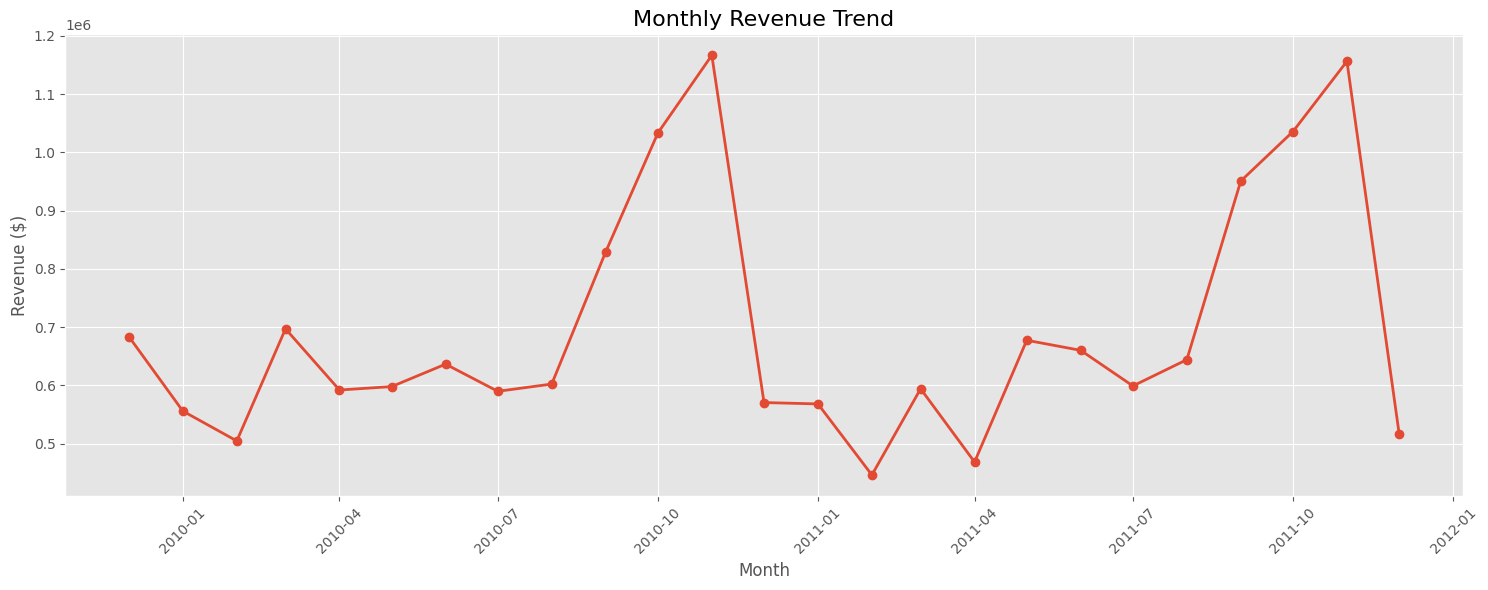

In [8]:
# ==========================================================
# Monthly Revenue Trend
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    monthly_summary.index,
    monthly_summary["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

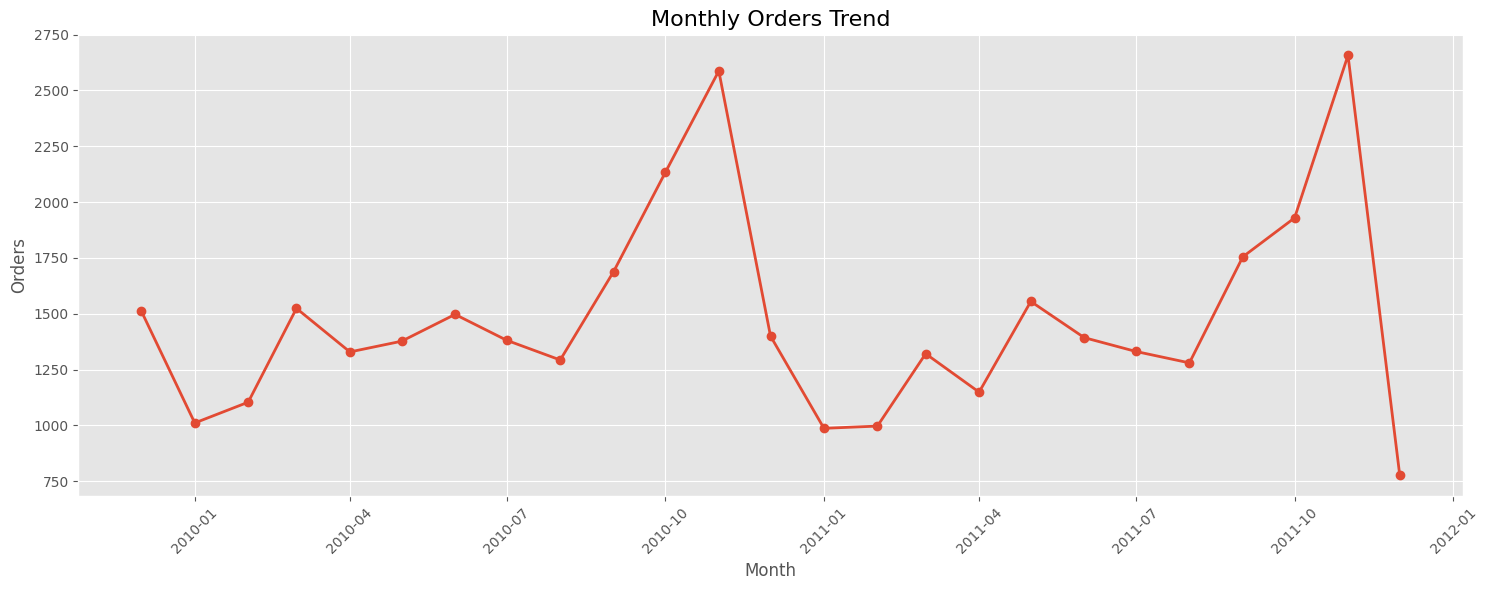

In [9]:
# ==========================================================
# Monthly Orders Trend
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    monthly_summary.index,
    monthly_summary["Orders"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Orders Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_orders_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

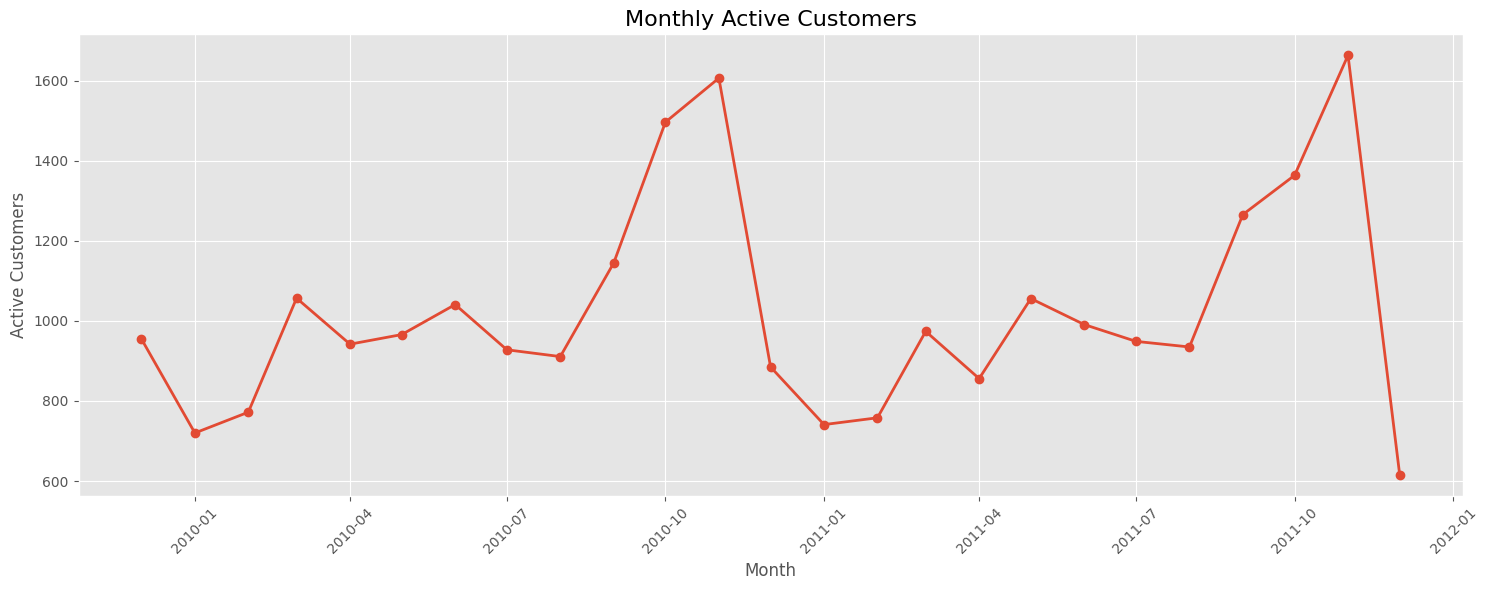

In [10]:
# ==========================================================
# Monthly Active Customers
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    monthly_summary.index,
    monthly_summary["Customers"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Active Customers", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Active Customers")
plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_active_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Quarterly and Year-over-Year Analysis

This section summarizes business performance at a higher level.

The analysis focuses on:

- Quarterly Revenue
- Quarterly Orders
- Yearly Revenue
- Yearly Orders

These views help identify long-term business growth and seasonal patterns.

In [11]:
# ==========================================================
# Quarterly Business Summary
# ==========================================================

quarterly_summary = (
    df.groupby(["InvoiceYear", "InvoiceQuarter"])
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("InvoiceID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

print("=" * 70)
print("QUARTERLY BUSINESS SUMMARY")
print("=" * 70)

display(quarterly_summary)

QUARTERLY BUSINESS SUMMARY


,InvoiceYear,InvoiceQuarter,Revenue,Orders,Customers,Quantity
0,2009,4,"683,504.01",1512,955,398660
1,2010,1,"1,757,340.10",3639,1803,1244043
2,2010,2,"1,826,186.51",4203,2047,1125419
3,2010,3,"2,020,974.72",4363,2060,1344327
4,2010,4,"2,769,994.76",6120,2670,1560548
5,2011,1,"1,608,267.99",3305,1776,961082
6,2011,2,"1,805,775.53",4097,1991,1027244
7,2011,3,"2,193,704.14",4366,2161,1308385
8,2011,4,"2,709,056.50",5364,2560,1544244


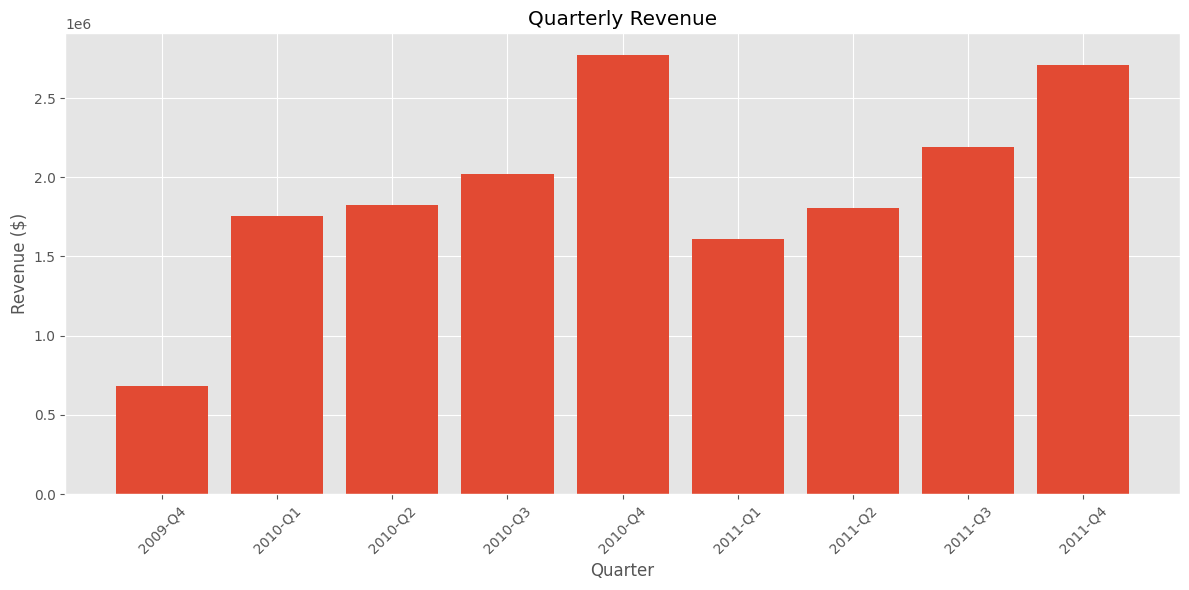

In [12]:
# ==========================================================
# Quarterly Revenue
# ==========================================================

quarter_labels = (
    quarterly_summary["InvoiceYear"].astype(str)
    + "-Q"
    + quarterly_summary["InvoiceQuarter"].astype(str)
)

plt.figure(figsize=(12,6))

plt.bar(
    quarter_labels,
    quarterly_summary["Revenue"]
)

plt.title("Quarterly Revenue")
plt.xlabel("Quarter")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "quarterly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# ==========================================================
# Yearly Business Summary
# ==========================================================

yearly_summary = (
    df.groupby("InvoiceYear")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("InvoiceID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Quantity=("Quantity", "sum")
      )
)

print("=" * 70)
print("YEARLY BUSINESS SUMMARY")
print("=" * 70)

display(yearly_summary)

YEARLY BUSINESS SUMMARY


,Revenue,Orders,Customers,Quantity
InvoiceYear,,,,
2009,"683,504.01",1512,955,398660
2010,"8,374,496.09",18325,4231,5274337
2011,"8,316,804.16",17132,4219,4840955


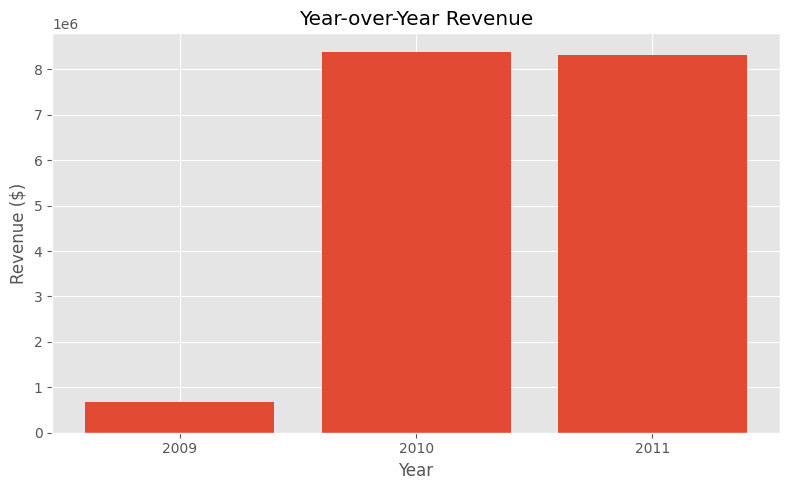

In [16]:
# ==========================================================
# Year-over-Year Revenue
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    yearly_summary.index.astype(str),
    yearly_summary["Revenue"]
)

plt.title("Year-over-Year Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue ($)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "yearly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Product Performance Analysis

This section analyzes product performance using three key metrics:

- Revenue generated
- Quantity sold
- Order frequency

The objective is to identify the products that contribute the most to the business and understand their sales patterns.

In [20]:
# ==========================================================
# Product Performance Summary
# ==========================================================

PRODUCT_COL = "ProductDescription"

product_summary = (
    df.groupby(["StockCode", PRODUCT_COL])
      .agg(
          Revenue=("TotalAmount", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("InvoiceID", "nunique")
      )
      .reset_index()
)

print("=" * 70)
print("PRODUCT PERFORMANCE SUMMARY")
print("=" * 70)

print(f"Total Products : {len(product_summary):,}")

display(product_summary.head())

PRODUCT PERFORMANCE SUMMARY
Total Products : 5,315


,StockCode,ProductDescription,Revenue,Quantity,Orders
0,10002,INFLATABLE POLITICAL GLOBE,"6,638.27",8479,297
1,10080,GROOVY CACTUS INFLATABLE,124.61,303,26
2,10109,BENDY COLOUR PENCILS,1.68,4,1
3,10120,DOGGY RUBBER,136.08,648,62
4,10123C,HEARTS WRAPPING TAPE,226.76,628,46


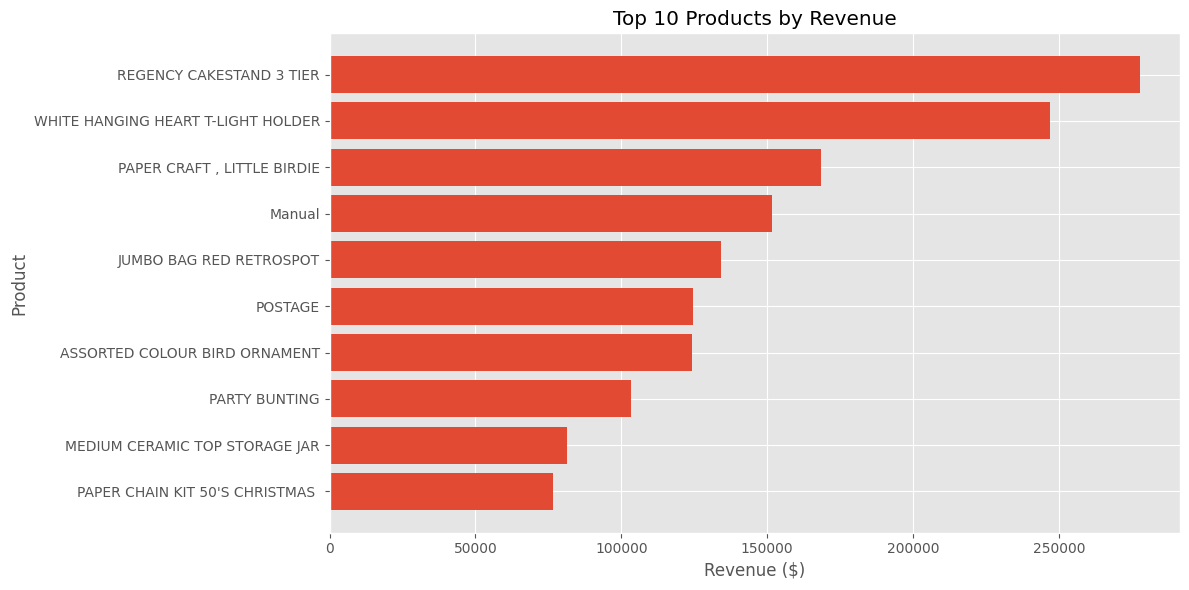

,StockCode,ProductDescription,Revenue,Quantity,Orders
1862,22423,REGENCY CAKESTAND 3 TIER,"277,656.25",24124,3317
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"247,048.01",91757,4888
3283,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
5309,M,Manual,"151,777.67",9384,620
4725,85099B,JUMBO BAG RED RETROSPOT,"134,307.44",74224,2612
5311,POST,POSTAGE,"124,648.04",5235,1803
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,"124,351.86",78234,2652
3627,47566,PARTY BUNTING,"103,283.38",23460,2077
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,195
1449,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"76,598.18",28380,1691


In [21]:
# ==========================================================
# Top 10 Products by Revenue
# ==========================================================

top_revenue_products = (
    product_summary
    .sort_values("Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_revenue_products[PRODUCT_COL],
    top_revenue_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top10_products_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(top_revenue_products)

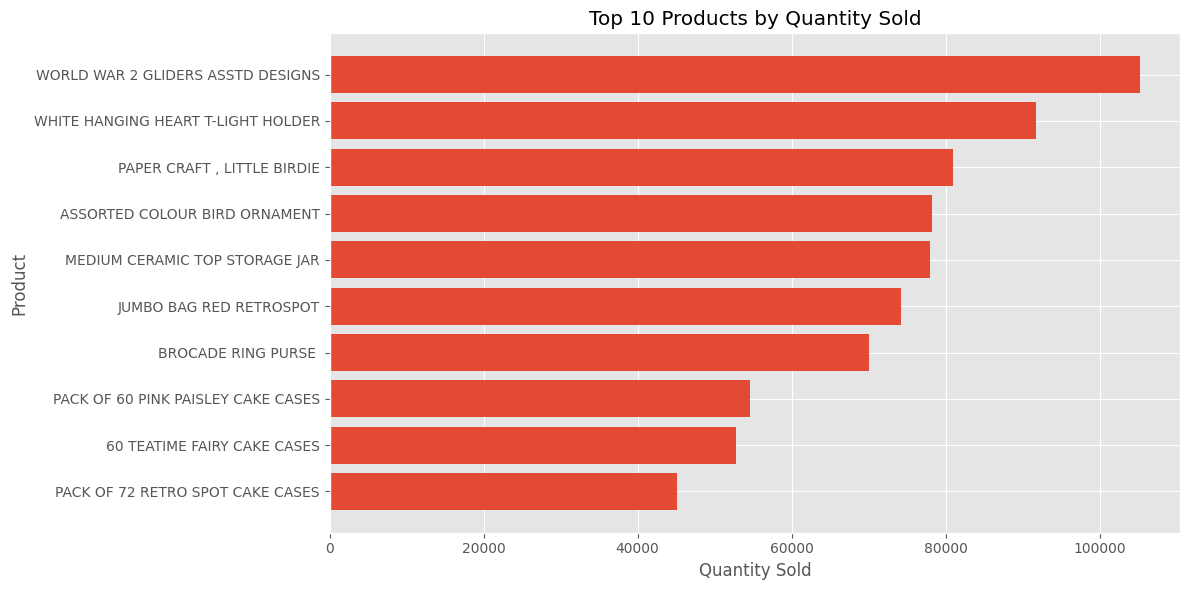

,StockCode,ProductDescription,Revenue,Quantity,Orders
4031,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"24,098.03",105185,920
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"247,048.01",91757,4888
3283,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,"124,351.86",78234,2652
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,195
4725,85099B,JUMBO BAG RED RETROSPOT,"134,307.44",74224,2612
115,17003,BROCADE RING PURSE,"14,640.96",70082,387
1357,21977,PACK OF 60 PINK PAISLEY CAKE CASES,"26,407.35",54592,1578
4595,84991,60 TEATIME FAIRY CAKE CASES,"25,785.92",52828,1765
658,21212,PACK OF 72 RETRO SPOT CAKE CASES,"21,838.23",45129,1160


In [22]:
# ==========================================================
# Top 10 Products by Quantity Sold
# ==========================================================

top_quantity_products = (
    product_summary
    .sort_values("Quantity", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_quantity_products[PRODUCT_COL],
    top_quantity_products["Quantity"]
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top10_products_quantity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(top_quantity_products)

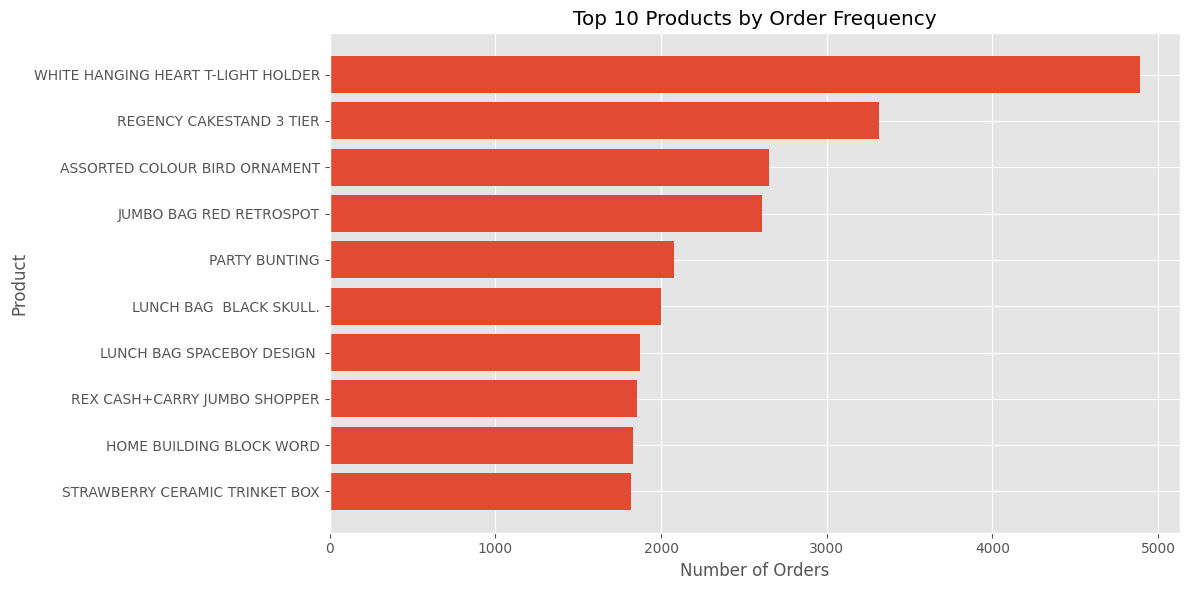

,StockCode,ProductDescription,Revenue,Quantity,Orders
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"247,048.01",91757,4888
1862,22423,REGENCY CAKESTAND 3 TIER,"277,656.25",24124,3317
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,"124,351.86",78234,2652
4725,85099B,JUMBO BAG RED RETROSPOT,"134,307.44",74224,2612
3627,47566,PARTY BUNTING,"103,283.38",23460,2077
281,20727,LUNCH BAG BLACK SKULL.,"39,904.00",25392,1997
1810,22382,LUNCH BAG SPACEBOY DESIGN,"30,131.70",18834,1874
505,21034,REX CASH+CARRY JUMBO SHOPPER,"3,689.80",3884,1857
1177,21754,HOME BUILDING BLOCK WORD,"42,453.11",7231,1831
679,21232,STRAWBERRY CERAMIC TRINKET BOX,"39,682.67",33899,1818


In [23]:
# ==========================================================
# Top 10 Products by Order Frequency
# ==========================================================

top_order_products = (
    product_summary
    .sort_values("Orders", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_order_products[PRODUCT_COL],
    top_order_products["Orders"]
)

plt.title("Top 10 Products by Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top10_products_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(top_order_products)

In [24]:
# ==========================================================
# Product Performance Validation
# ==========================================================

print("=" * 70)
print("PRODUCT PERFORMANCE VALIDATION")
print("=" * 70)

print(f"Unique Products : {len(product_summary):,}")
print(f"Highest Revenue Product : {top_revenue_products.iloc[0][PRODUCT_COL]}")
print(f"Highest Quantity Product : {top_quantity_products.iloc[0][PRODUCT_COL]}")
print(f"Most Frequently Ordered Product : {top_order_products.iloc[0][PRODUCT_COL]}")

PRODUCT PERFORMANCE VALIDATION
Unique Products : 5,315
Highest Revenue Product : REGENCY CAKESTAND 3 TIER
Highest Quantity Product : WORLD WAR 2 GLIDERS ASSTD DESIGNS
Most Frequently Ordered Product : WHITE HANGING HEART T-LIGHT HOLDER


In [25]:
# ==========================================================
# Special Product Validation
# ==========================================================

special_products = [
    "POSTAGE",
    "Manual",
    "Discount",
    "DOTCOM POSTAGE",
    "BANK CHARGES"
]

special_df = product_summary[
    product_summary["ProductDescription"]
    .isin(special_products)
]

print("=" * 70)
print("SPECIAL PRODUCT ENTRIES")
print("=" * 70)

display(
    special_df.sort_values(
        "Revenue",
        ascending=False
    )
)

SPECIAL PRODUCT ENTRIES


,StockCode,ProductDescription,Revenue,Quantity,Orders
5309,M,Manual,"151,777.67",9384,620
5311,POST,POSTAGE,"124,648.04",5235,1803
5308,DOT,DOTCOM POSTAGE,"11,906.36",16,16
5307,D,Discount,397.89,196,5


## Pareto Analysis (80/20 Rule)

Pareto Analysis helps identify the products that contribute the most to total revenue.

Business Objective:

- Rank products by revenue.
- Calculate cumulative revenue contribution.
- Determine how many products generate 80% of total revenue.
- Support inventory optimization and product prioritization.

In [28]:
# ==========================================================
# Retail Products Dataset
# ==========================================================

NON_RETAIL_PRODUCTS = [
    "POSTAGE",
    "Manual",
    "Discount",
    "DOTCOM POSTAGE",
    "BANK CHARGES"
]

retail_products = product_summary[
    ~product_summary["ProductDescription"].isin(NON_RETAIL_PRODUCTS)
].copy()

print(f"Retail Products: {len(retail_products):,}")

Retail Products: 5,311


In [29]:
# ==========================================================
# Pareto Analysis Dataset
# ==========================================================

pareto_df = (
    retail_products
    .sort_values("Revenue", ascending=False)
    .reset_index(drop=True)
)

pareto_df["RevenuePercent"] = (
    pareto_df["Revenue"] /
    pareto_df["Revenue"].sum()
) * 100

pareto_df["CumulativeRevenue"] = (
    pareto_df["RevenuePercent"].cumsum()
)

display(pareto_df.head())

,StockCode,ProductDescription,Revenue,Quantity,Orders,RevenuePercent,CumulativeRevenue
0,22423,REGENCY CAKESTAND 3 TIER,"277,656.25",24124,3317,1.63,1.63
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"247,048.01",91757,4888,1.45,3.07
2,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,0.99,4.06
3,85099B,JUMBO BAG RED RETROSPOT,"134,307.44",74224,2612,0.79,4.84
4,84879,ASSORTED COLOUR BIRD ORNAMENT,"124,351.86",78234,2652,0.73,5.57


In [30]:
# ==========================================================
# 80 Percent Revenue Threshold
# ==========================================================

top_80_products = pareto_df[
    pareto_df["CumulativeRevenue"] <= 80
]

num_products_80 = len(top_80_products)

total_products = len(pareto_df)

percentage_products = (
    num_products_80 /
    total_products
) * 100

print("=" * 70)
print("PARETO ANALYSIS")
print("=" * 70)

print(f"Products contributing 80% Revenue : {num_products_80:,}")
print(f"Percentage of Products            : {percentage_products:.2f}%")
print(f"Total Products                    : {total_products:,}")

PARETO ANALYSIS
Products contributing 80% Revenue : 1,151
Percentage of Products            : 21.67%
Total Products                    : 5,311


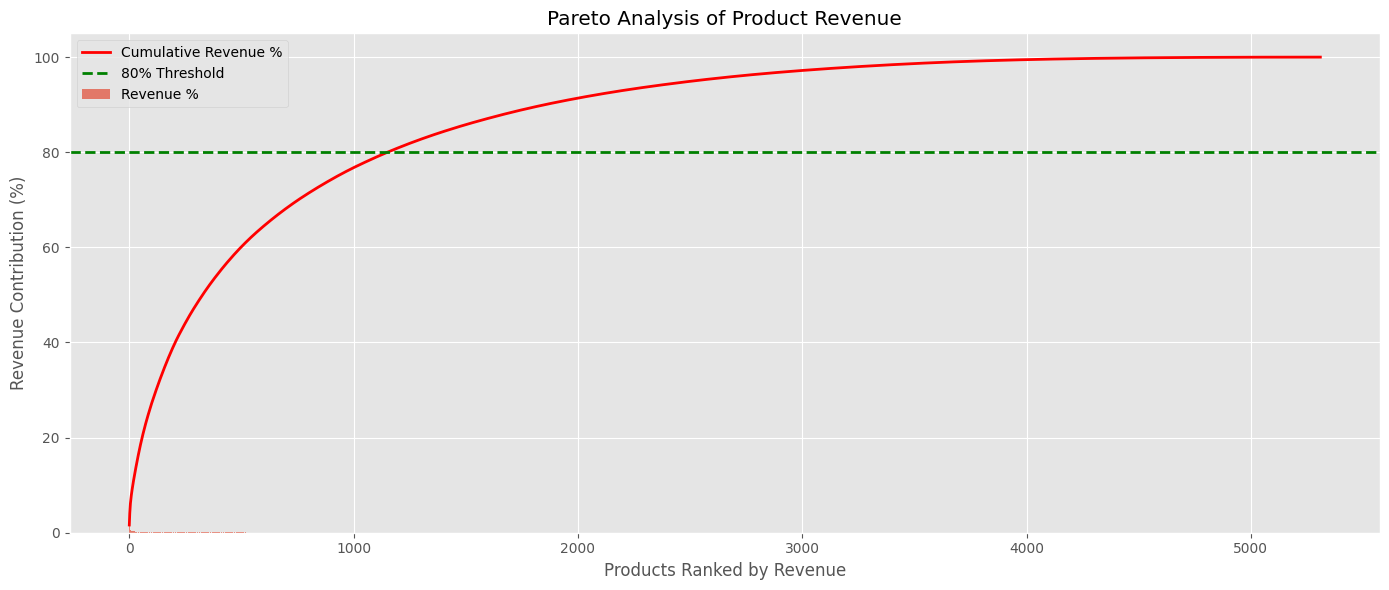

In [31]:
# ==========================================================
# Pareto Chart
# ==========================================================

plt.figure(figsize=(14,6))

plt.bar(
    range(len(pareto_df)),
    pareto_df["RevenuePercent"],
    alpha=0.7,
    label="Revenue %"
)

plt.plot(
    range(len(pareto_df)),
    pareto_df["CumulativeRevenue"],
    color="red",
    linewidth=2,
    label="Cumulative Revenue %"
)

plt.axhline(
    80,
    color="green",
    linestyle="--",
    linewidth=2,
    label="80% Threshold"
)

plt.title("Pareto Analysis of Product Revenue")
plt.xlabel("Products Ranked by Revenue")
plt.ylabel("Revenue Contribution (%)")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pareto_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# ==========================================================
# Top Revenue Contributors
# ==========================================================

display(
    top_80_products[
        [
            "StockCode",
            "ProductDescription",
            "Revenue",
            "CumulativeRevenue"
        ]
    ].head(20)
)

,StockCode,ProductDescription,Revenue,CumulativeRevenue
0,22423,REGENCY CAKESTAND 3 TIER,"277,656.25",1.63
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"247,048.01",3.07
2,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",4.06
3,85099B,JUMBO BAG RED RETROSPOT,"134,307.44",4.84
4,84879,ASSORTED COLOUR BIRD ORNAMENT,"124,351.86",5.57
5,47566,PARTY BUNTING,"103,283.38",6.18
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",6.65
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"76,598.18",7.10
8,79321,CHILLI LIGHTS,"69,084.30",7.50
9,85099F,JUMBO BAG STRAWBERRY,"64,127.77",7.88


In [33]:
# ==========================================================
# Pareto Summary
# ==========================================================

print("=" * 70)
print("PARETO SUMMARY")
print("=" * 70)

print(f"Total Products              : {total_products:,}")
print(f"Top Revenue Products        : {num_products_80:,}")
print(f"Share of Product Catalogue  : {percentage_products:.2f}%")
print("Revenue Covered             : 80%")

PARETO SUMMARY
Total Products              : 5,311
Top Revenue Products        : 1,151
Share of Product Catalogue  : 21.67%
Revenue Covered             : 80%


### Business Insights

- Approximately **21.67% of products generate 80% of total revenue**.
- This closely follows the Pareto Principle (80/20 Rule), indicating that a relatively small portion of the product catalog drives the majority of sales.
- These high-performing products should be prioritized for inventory planning, demand forecasting, pricing strategies, and promotional campaigns.
- Low-contributing products can be reviewed for rationalization, bundling, or targeted marketing strategies.

## Customer Analysis

Customer Analysis helps understand purchasing behavior and identify high-value customers.

Business Objectives:

- Identify the highest revenue-generating customers.
- Analyze purchase frequency.
- Understand customer spending distribution.
- Measure customer lifetime value (basic).
- Support future customer segmentation and recommendation models.

In [34]:
# ==========================================================
# Customer Performance Summary
# ==========================================================

customer_summary = (
    df.groupby("CustomerID")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("InvoiceID", "nunique"),
          Quantity=("Quantity", "sum"),
          FirstPurchase=("InvoiceDate", "min"),
          LastPurchase=("InvoiceDate", "max")
      )
      .reset_index()
)

customer_summary["CustomerLifetimeDays"] = (
    customer_summary["LastPurchase"] -
    customer_summary["FirstPurchase"]
).dt.days + 1

print("=" * 70)
print("CUSTOMER PERFORMANCE SUMMARY")
print("=" * 70)

print(f"Total Customers : {len(customer_summary):,}")

display(customer_summary.head())

CUSTOMER PERFORMANCE SUMMARY
Total Customers : 5,878


,CustomerID,Revenue,Orders,Quantity,FirstPurchase,LastPurchase,CustomerLifetimeDays
0,"12,346.00","77,556.46",12,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,401
1,"12,347.00","4,921.53",8,2967,2010-10-31 14:20:00,2011-12-07 15:52:00,403
2,"12,348.00","2,019.40",5,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,363
3,"12,349.00","4,428.69",4,1624,2010-04-29 13:20:00,2011-11-21 09:51:00,571
4,"12,350.00",334.40,1,197,2011-02-02 16:01:00,2011-02-02 16:01:00,1


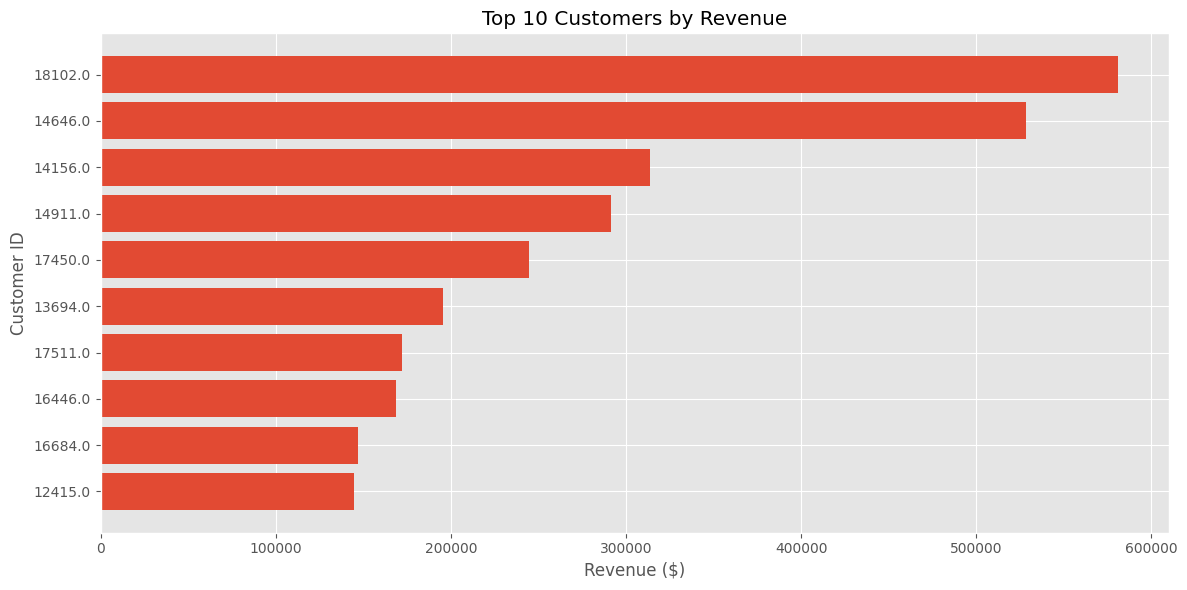

,CustomerID,Revenue,Orders,Quantity,FirstPurchase,LastPurchase,CustomerLifetimeDays
5692,"18,102.00","580,987.04",145,181645,2009-12-01 09:24:00,2011-12-09 11:50:00,739
2277,"14,646.00","528,602.52",151,367193,2009-12-02 16:52:00,2011-12-08 12:12:00,736
1789,"14,156.00","313,437.62",156,164325,2009-12-01 12:30:00,2011-11-30 10:54:00,729
2538,"14,911.00","291,420.81",398,147972,2009-12-01 11:41:00,2011-12-08 15:54:00,738
5050,"17,450.00","244,784.25",51,83914,2010-09-27 16:59:00,2011-12-01 13:29:00,430
1331,"13,694.00","195,640.69",143,188201,2009-12-04 15:26:00,2011-12-06 09:32:00,732
5109,"17,511.00","172,132.87",60,117174,2009-12-02 10:52:00,2011-12-07 10:12:00,735
4061,"16,446.00","168,472.50",2,80997,2011-05-18 09:52:00,2011-12-09 09:15:00,205
4295,"16,684.00","147,142.77",55,104810,2009-12-07 12:56:00,2011-12-05 14:06:00,729
68,"12,415.00","144,458.37",28,91447,2010-06-30 08:30:00,2011-11-15 14:22:00,504


In [35]:
# ==========================================================
# Top 10 Customers by Revenue
# ==========================================================

top_customers = (
    customer_summary
    .sort_values("Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_customers["CustomerID"].astype(str),
    top_customers["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top_customers_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(top_customers)

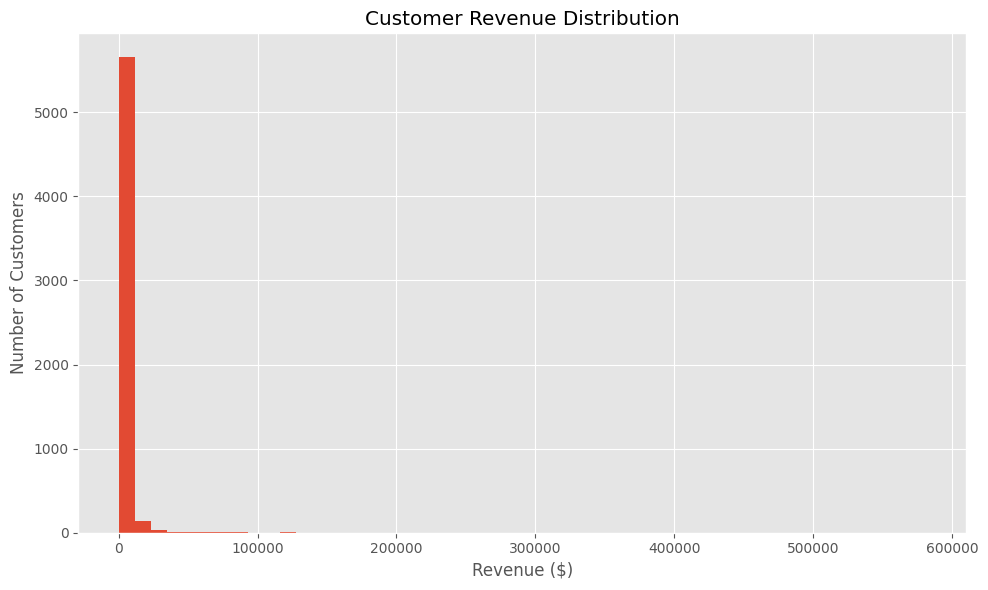

In [36]:
# ==========================================================
# Customer Revenue Distribution
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    customer_summary["Revenue"],
    bins=50
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue ($)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "customer_revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

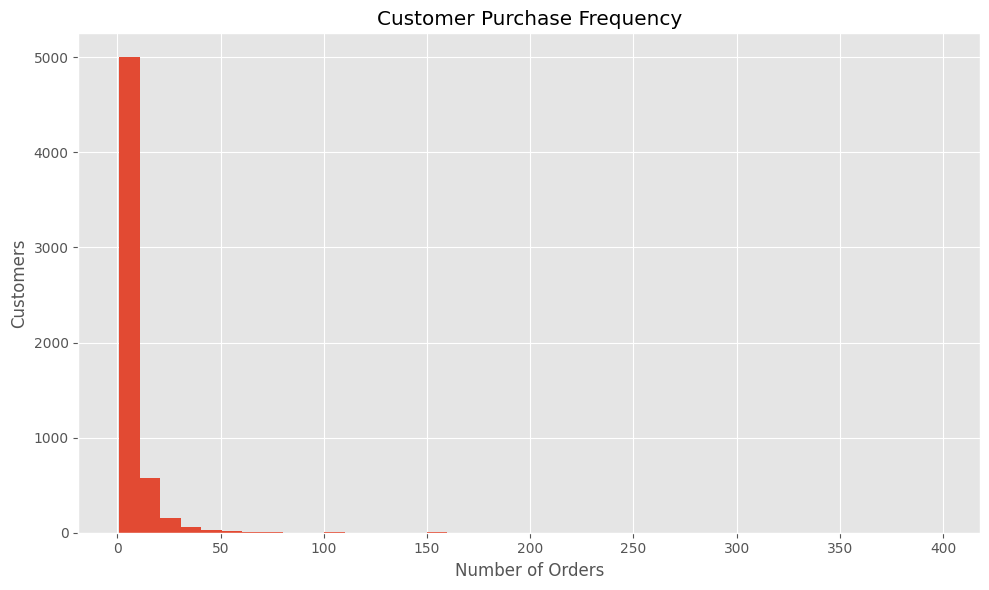

In [37]:
# ==========================================================
# Customer Purchase Frequency
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    customer_summary["Orders"],
    bins=40
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "customer_purchase_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

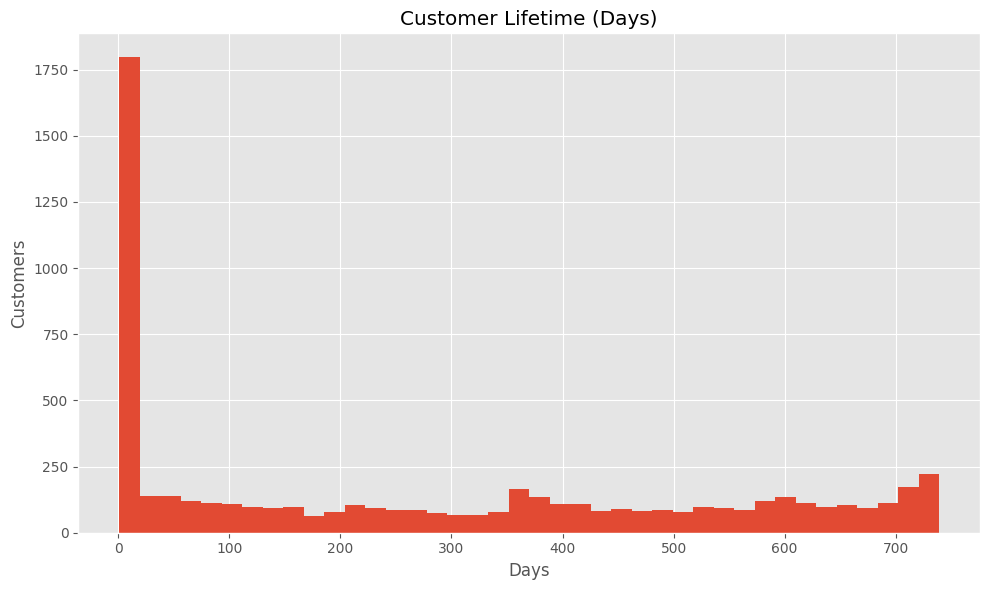

In [38]:
# ==========================================================
# Customer Lifetime Analysis
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    customer_summary["CustomerLifetimeDays"],
    bins=40
)

plt.title("Customer Lifetime (Days)")
plt.xlabel("Days")
plt.ylabel("Customers")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "customer_lifetime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# ==========================================================
# Customer Metrics
# ==========================================================

repeat_customers = (
    customer_summary["Orders"] > 1
).sum()

one_time_customers = (
    customer_summary["Orders"] == 1
).sum()

print("=" * 70)
print("CUSTOMER ANALYSIS SUMMARY")
print("=" * 70)

print(f"Total Customers      : {len(customer_summary):,}")
print(f"Repeat Customers     : {repeat_customers:,}")
print(f"One-Time Customers   : {one_time_customers:,}")
print(f"Average Revenue      : ${customer_summary['Revenue'].mean():,.2f}")
print(f"Median Revenue       : ${customer_summary['Revenue'].median():,.2f}")
print(f"Average Orders       : {customer_summary['Orders'].mean():.2f}")

CUSTOMER ANALYSIS SUMMARY
Total Customers      : 5,878
Repeat Customers     : 4,255
One-Time Customers   : 1,623
Average Revenue      : $2,955.90
Median Revenue       : $867.74
Average Orders       : 6.29


### Business Insights

- Approximately **72.39%** of customers are repeat buyers, indicating strong customer loyalty.
- The average customer revenue ($2,955.90) is significantly higher than the median ($867.74), suggesting a small number of high-value customers contribute disproportionately to total revenue.
- Revenue and purchase frequency distributions are highly right-skewed, with a long tail of high-value customers.
- Customer lifetime spans up to **739 days**, indicating many customers remain active throughout the dataset period.
- These observations support future RFM segmentation, churn prediction, and personalized recommendation models.

## Country Analysis

Country Analysis evaluates business performance across different geographic regions.

Business Objectives:

- Identify the highest revenue-generating countries.
- Compare customer distribution across countries.
- Analyze order volume by country.
- Calculate Average Order Value (AOV) by country.
- Discover market concentration and international sales opportunities.

In [40]:
# ==========================================================
# Country Performance Summary
# ==========================================================

country_summary = (
    df.groupby("Country")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Orders=("InvoiceID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

country_summary["AverageOrderValue"] = (
    country_summary["Revenue"] /
    country_summary["Orders"]
)

country_summary = country_summary.sort_values(
    "Revenue",
    ascending=False
)

print("=" * 70)
print("COUNTRY PERFORMANCE SUMMARY")
print("=" * 70)

print(f"Total Countries : {len(country_summary)}")

display(country_summary.head(10))

COUNTRY PERFORMANCE SUMMARY
Total Countries : 41


,Country,Revenue,Orders,Customers,Quantity,AverageOrderValue
38,United Kingdom,"14,389,234.92",33541,5350,8532411,429.00
10,EIRE,"616,570.54",567,5,318021,"1,087.43"
24,Netherlands,"554,038.09",228,22,383879,"2,429.99"
14,Germany,"425,019.71",789,107,225154,538.68
13,France,"348,768.96",614,95,270288,568.03
0,Australia,"169,283.46",95,15,103759,"1,781.93"
32,Spain,"108,332.49",154,41,50307,703.46
34,Switzerland,"100,061.94",90,22,52227,"1,111.80"
33,Sweden,"91,515.82",104,19,88495,879.96
9,Denmark,"68,580.69",43,12,237471,"1,594.90"


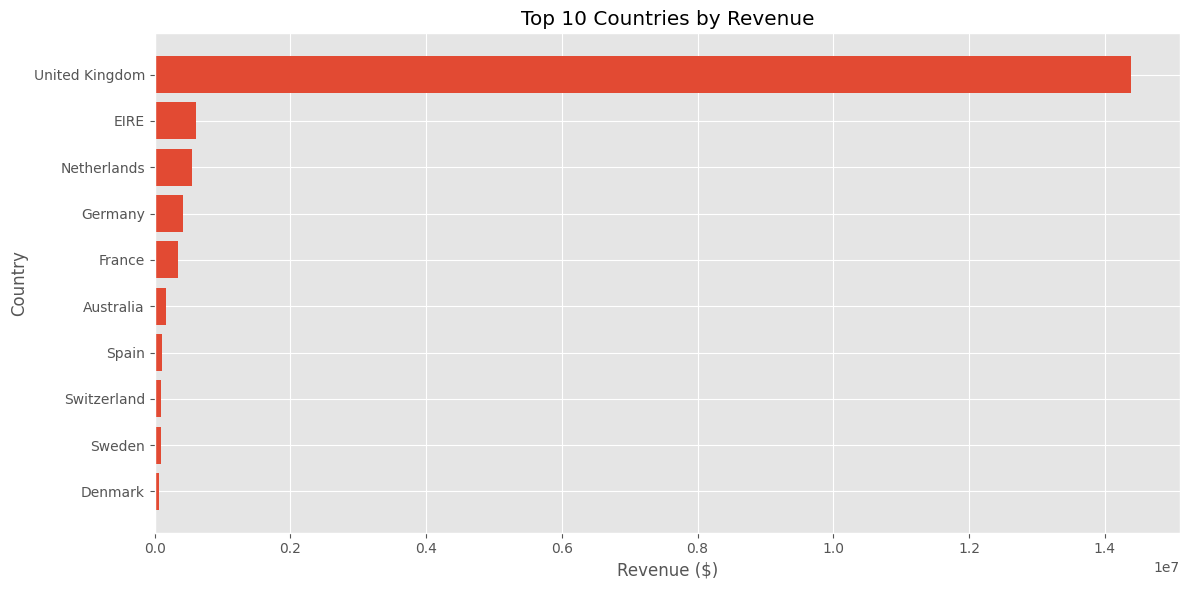

In [41]:
# ==========================================================
# Top 10 Countries by Revenue
# ==========================================================

top_countries = country_summary.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_countries["Country"],
    top_countries["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top_countries_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

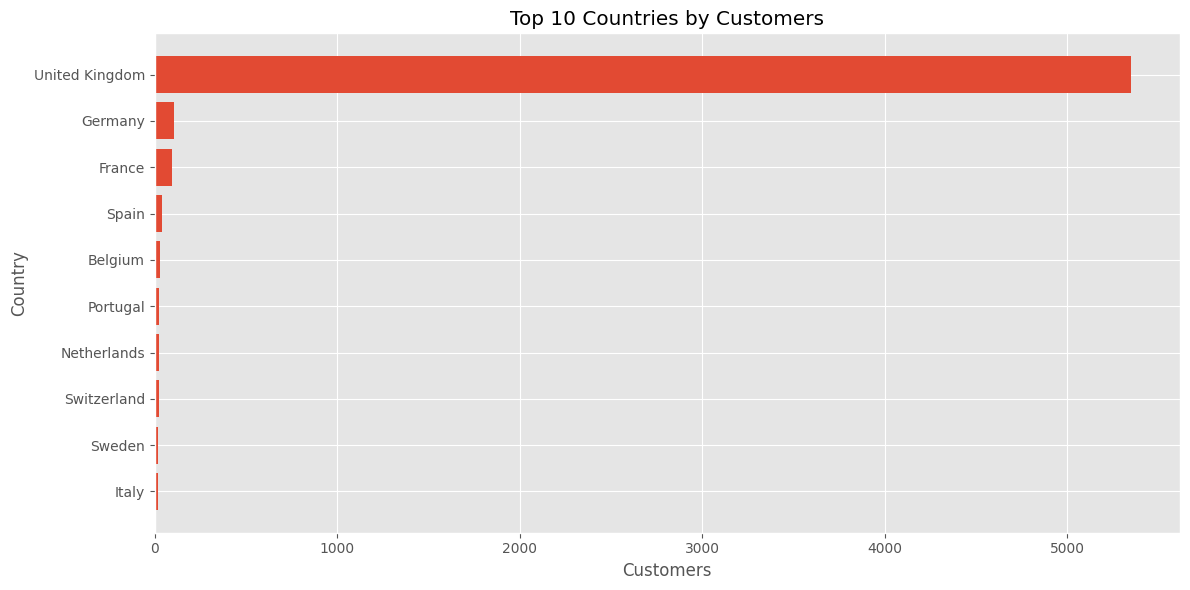

In [42]:
# ==========================================================
# Top 10 Countries by Customers
# ==========================================================

top_customer_countries = (
    country_summary
    .sort_values("Customers", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_customer_countries["Country"],
    top_customer_countries["Customers"]
)

plt.title("Top 10 Countries by Customers")
plt.xlabel("Customers")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top_countries_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

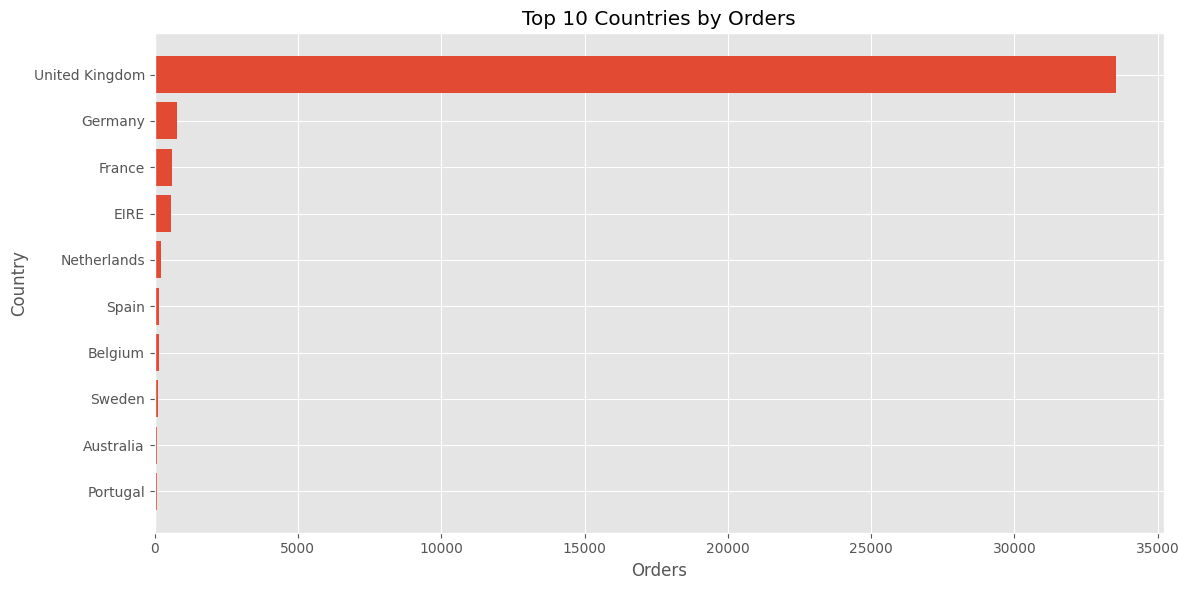

In [43]:
# ==========================================================
# Top 10 Countries by Orders
# ==========================================================

top_order_countries = (
    country_summary
    .sort_values("Orders", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_order_countries["Country"],
    top_order_countries["Orders"]
)

plt.title("Top 10 Countries by Orders")
plt.xlabel("Orders")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top_countries_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

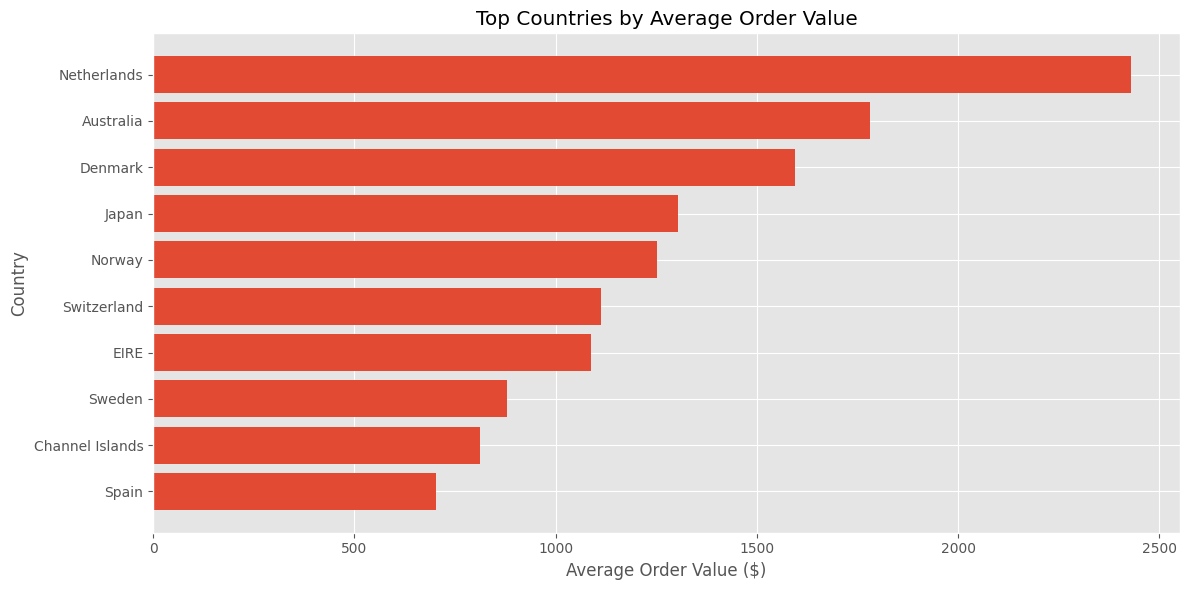

,Country,Revenue,Orders,Customers,Quantity,AverageOrderValue
24,Netherlands,"554,038.09",228,22,383879,"2,429.99"
0,Australia,"169,283.46",95,15,103759,"1,781.93"
9,Denmark,"68,580.69",43,12,237471,"1,594.90"
19,Japan,"43,023.91",33,10,31643,"1,303.75"
26,Norway,"56,322.50",45,13,23621,"1,251.61"
34,Switzerland,"100,061.94",90,22,52227,"1,111.80"
10,EIRE,"616,570.54",567,5,318021,"1,087.43"
33,Sweden,"91,515.82",104,19,88495,879.96
6,Channel Islands,"44,623.33",55,13,21396,811.33
32,Spain,"108,332.49",154,41,50307,703.46


In [44]:
# ==========================================================
# Average Order Value by Country
# ==========================================================

top_aov = (
    country_summary[
        country_summary["Orders"] >= 20
    ]
    .sort_values("AverageOrderValue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_aov["Country"],
    top_aov["AverageOrderValue"]
)

plt.title("Top Countries by Average Order Value")
plt.xlabel("Average Order Value ($)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "country_average_order_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(top_aov)

In [45]:
# ==========================================================
# Country Analysis Summary
# ==========================================================

print("=" * 70)
print("COUNTRY ANALYSIS SUMMARY")
print("=" * 70)

print(f"Countries Served : {len(country_summary)}")

print(
    f"Highest Revenue Country : "
    f"{country_summary.iloc[0]['Country']}"
)

print(
    f"Highest Revenue : "
    f"${country_summary.iloc[0]['Revenue']:,.2f}"
)

print(
    f"Highest Customer Base : "
    f"{top_customer_countries.iloc[0]['Country']}"
)

print(
    f"Highest Order Volume : "
    f"{top_order_countries.iloc[0]['Country']}"
)

COUNTRY ANALYSIS SUMMARY
Countries Served : 41
Highest Revenue Country : United Kingdom
Highest Revenue : $14,389,234.92
Highest Customer Base : United Kingdom
Highest Order Volume : United Kingdom


# Basket Analysis

Basket Analysis evaluates customer purchasing behavior by examining
basket size and basket value.

Business Objectives:

- Analyze the number of products purchased per order.
- Understand basket value distribution.
- Study the relationship between basket size and basket value.

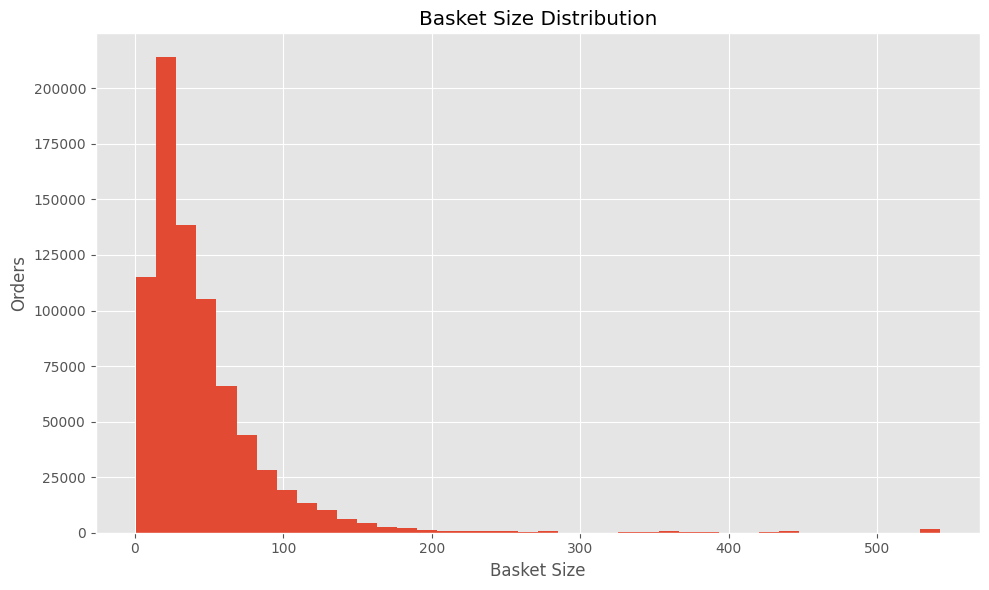

In [46]:
# ==========================================================
# Basket Size Distribution
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["BasketSize"],
    bins=40
)

plt.title("Basket Size Distribution")
plt.xlabel("Basket Size")
plt.ylabel("Orders")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "basket_size_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

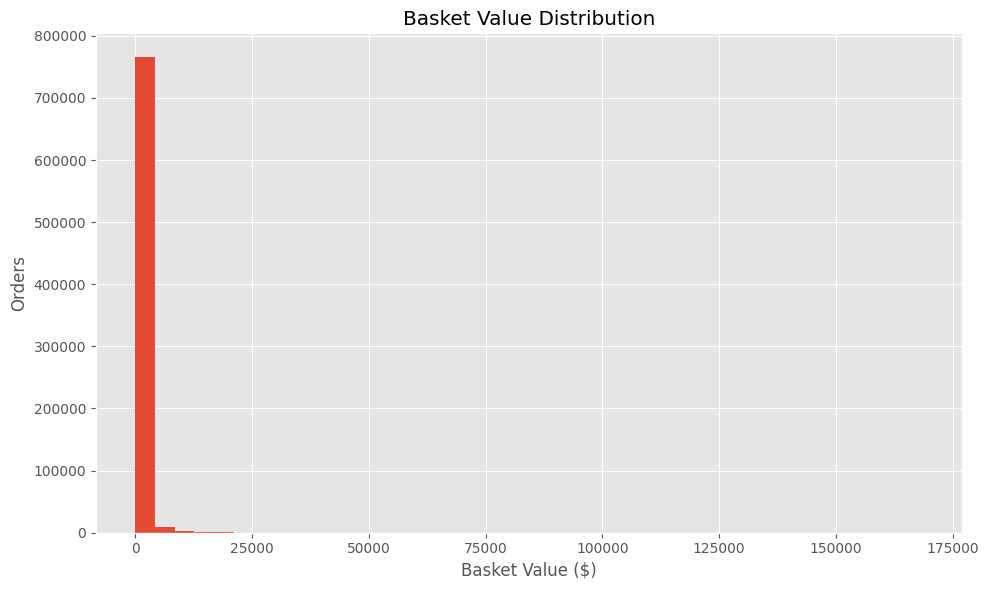

In [47]:
# ==========================================================
# Basket Value Distribution
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["BasketValue"],
    bins=40
)

plt.title("Basket Value Distribution")
plt.xlabel("Basket Value ($)")
plt.ylabel("Orders")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "basket_value_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

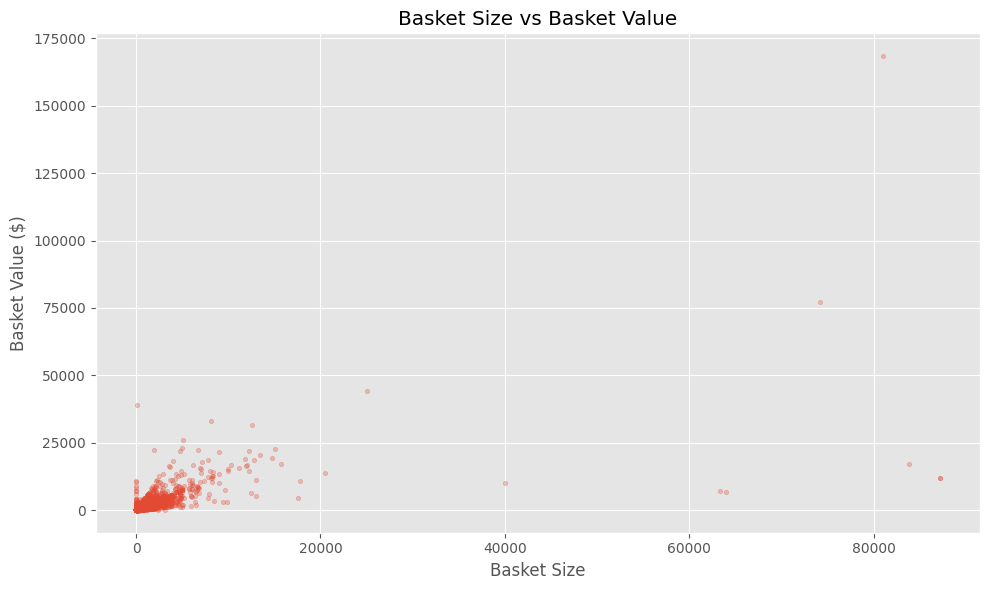

In [48]:
# ==========================================================
# Basket Size vs Basket Value
# ==========================================================

basket_summary = (
    df.groupby("InvoiceID")
      .agg(
          BasketSize=("Quantity", "sum"),
          BasketValue=("TotalAmount", "sum")
      )
      .reset_index()
)

plt.figure(figsize=(10,6))

plt.scatter(
    basket_summary["BasketSize"],
    basket_summary["BasketValue"],
    alpha=0.3,
    s=10
)

plt.title("Basket Size vs Basket Value")
plt.xlabel("Basket Size")
plt.ylabel("Basket Value ($)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "basket_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# ==========================================================
# Basket Metrics
# ==========================================================

print("=" * 70)
print("BASKET ANALYSIS")
print("=" * 70)

print(f"Average Basket Size : {basket_summary['BasketSize'].mean():.2f}")
print(f"Median Basket Size  : {basket_summary['BasketSize'].median():.2f}")

print(f"Average Basket Value : ${basket_summary['BasketValue'].mean():,.2f}")
print(f"Median Basket Value  : ${basket_summary['BasketValue'].median():,.2f}")

BASKET ANALYSIS
Average Basket Size : 284.40
Median Basket Size  : 151.00
Average Basket Value : $469.98
Median Basket Value  : $303.04


# Correlation Analysis

Correlation Analysis helps identify relationships between numerical variables and supports feature engineering for future machine learning models.

,Quantity,UnitPrice,TotalAmount,BasketSize,BasketValue
Quantity,1.00,-0.00,0.83,-0.03,0.24
UnitPrice,-0.00,1.00,0.14,-0.01,0.02
TotalAmount,0.83,0.14,1.00,-0.03,0.26
BasketSize,-0.03,-0.01,-0.03,1.00,0.39
BasketValue,0.24,0.02,0.26,0.39,1.00


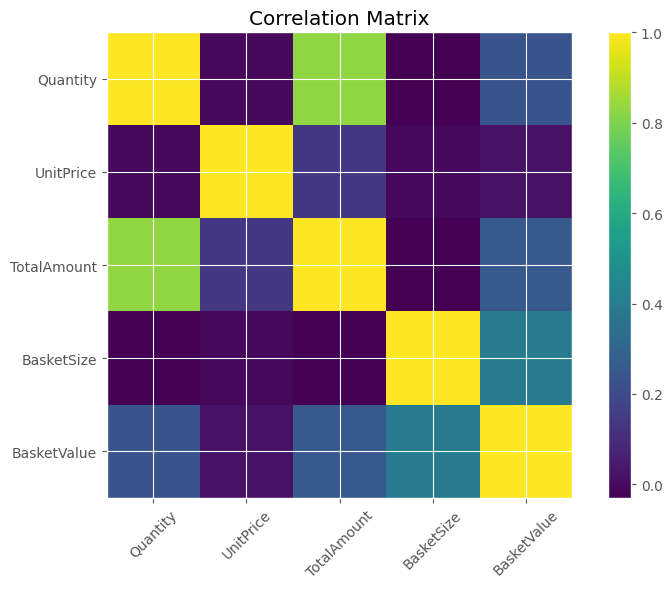

In [50]:
# ==========================================================
# Correlation Matrix
# ==========================================================

correlation_columns = [
    "Quantity",
    "UnitPrice",
    "TotalAmount",
    "BasketSize",
    "BasketValue"
]

corr = df[correlation_columns].corr()

display(corr)

plt.figure(figsize=(8,6))

plt.imshow(corr, interpolation="nearest")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Executive Business Summary

## Key Findings

### Sales Performance
- Total Revenue: **$17.37M**
- Total Orders: **36,969**
- Total Customers: **5,878**
- Total Products: **5,311**

### Customer Insights
- 72% of customers are repeat buyers.
- Revenue distribution is highly skewed, with a small group of high-value customers contributing significantly to total sales.

### Product Insights
- Approximately 22% of products contribute to 80% of total revenue (Pareto Principle).
- Several products consistently dominate both revenue and purchase frequency.

### Geographic Insights
- The United Kingdom is the dominant market.
- The Netherlands has the highest Average Order Value among countries with meaningful order volumes.

### Business Recommendations
- Prioritize inventory for high-performing products.
- Focus retention strategies on repeat customers.
- Expand marketing in high-value international markets.
- Use RFM segmentation for targeted campaigns.
- Use recommendation systems to improve cross-selling and basket value.

### Next Steps
The next notebook will perform **RFM Customer Segmentation**, which forms the foundation for customer clustering, churn prediction, and personalized recommendations.